
===== CSV LOADED =====
    dataset    modelo  n_classes_original      erro
0  dry-bean       EMQ                   7  0.004477
1  dry-bean  EMQ_BCTS                   7  0.004495
2  dry-bean        CC                   7  0.007429
3  dry-bean       PCC                   7  0.010558
4  dry-bean        AC                   7  0.005977
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'PAC', 'PCC', 'PWK', 'QMOSS', 'QMOSS_CALIBRATED', 'QMOSS_HYBRID']

Total original datasets: 24

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'PAC', 'PCC', 'PWK', 'QMOSS', 'QMOSS_CALIBRATED', 'QMOSS_HYBRID']

Total remaining models: 14

Datasets completos restantes: 24

✅ Todos os datasets possuem todos os modelos restantes.

===== AVERAGE RANK =====
              modelo  rank_dataset
0             KDEyML      3.125000
1             KDEyHD      4.291667
2             KDEyCS      4.458333
3                EMQ      5.333333
4               

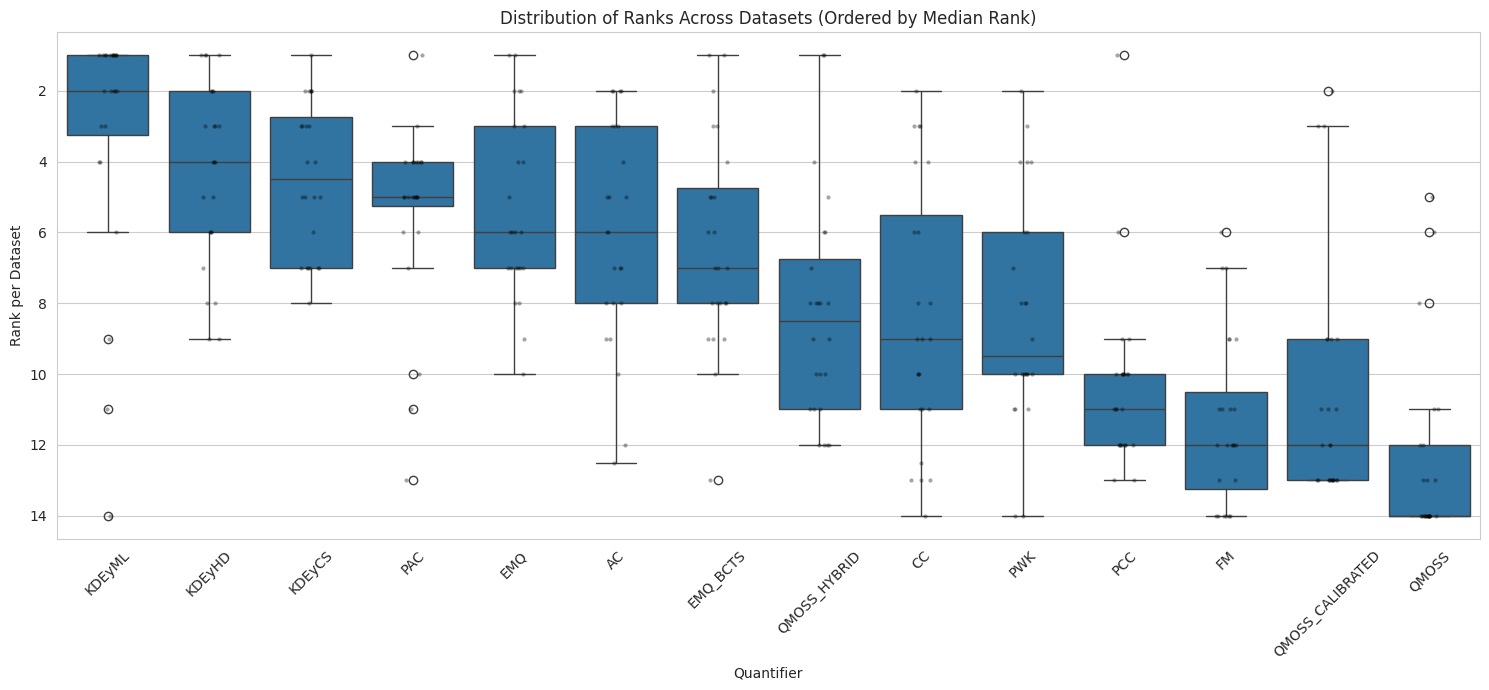

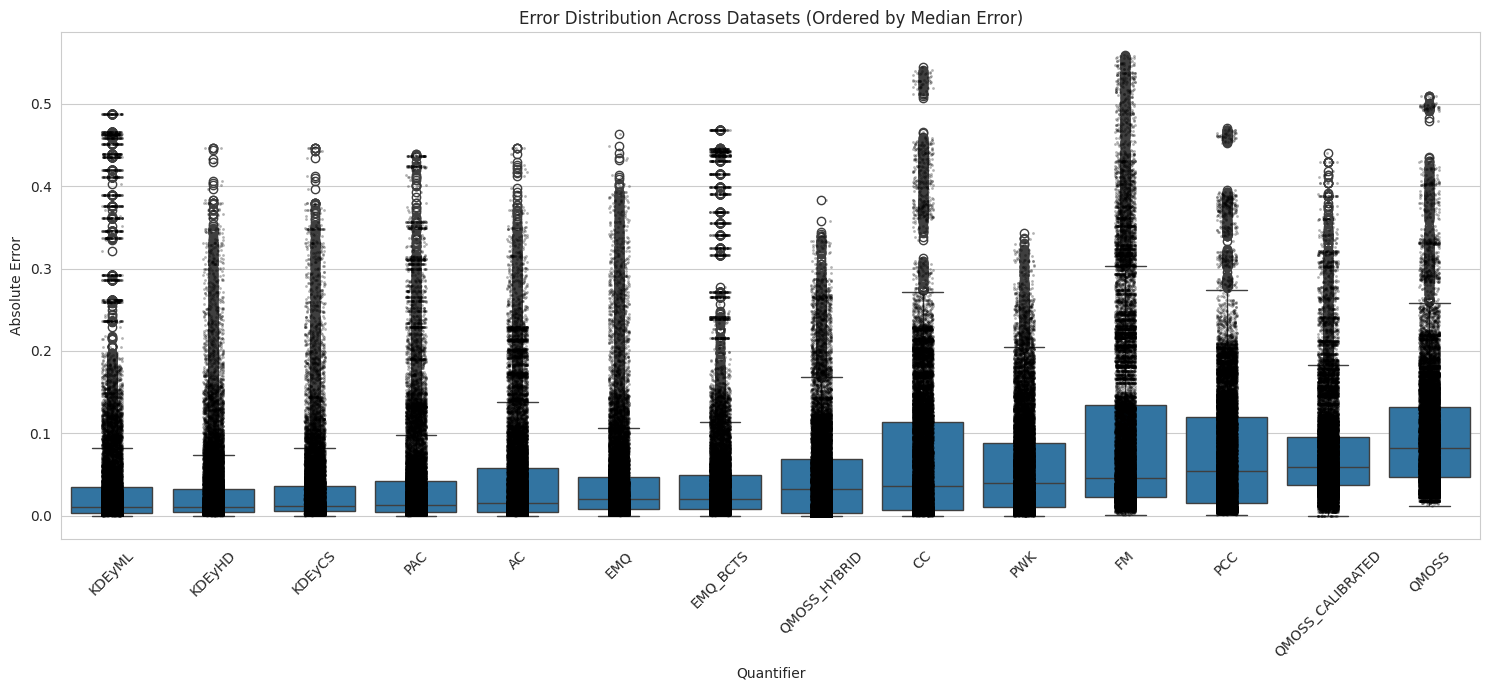


===== GLOBAL MEAN ERROR =====
              modelo  mean_error
0             KDEyHD    0.029526
1             KDEyCS    0.029987
2                EMQ    0.038352
3                PAC    0.038912
4             KDEyML    0.039477
5                 AC    0.043726
6           EMQ_BCTS    0.045657
7       QMOSS_HYBRID    0.047926
8                PWK    0.058062
9                 CC    0.070813
10  QMOSS_CALIBRATED    0.075239
11               PCC    0.075917
12             QMOSS    0.098327
13                FM    0.099331

===== GLOBAL MEDIAN ERROR =====
              modelo  median_error
0             KDEyML      0.010132
1             KDEyHD      0.010999
2             KDEyCS      0.012285
3                PAC      0.013601
4                 AC      0.015794
5                EMQ      0.019807
6           EMQ_BCTS      0.020010
7       QMOSS_HYBRID      0.032782
8                 CC      0.036000
9                PWK      0.040000
10                FM      0.045691
11               PCC 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "exp_results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"QMOSS_\d+_CALIBRATED",
    value="QMOSS_CALIBRATED",
    regex=True
)

df["modelo"] = df["modelo"].replace(
    to_replace=r"QMOSS_\d+_HYBRID",
    value="QMOSS_HYBRID",
    regex=True
)

df["modelo"] = df["modelo"].replace(
    to_replace=r"QMOSS_\d+$",
    value="QMOSS",
    regex=True
)

print(sorted(df["modelo"].unique()))

# ============================================================
# DATASETS ORIGINAIS
# ============================================================

all_datasets = sorted(df["dataset"].unique())

print(f"\nTotal original datasets: {len(all_datasets)}")

# ============================================================
# REMOVER MODELOS
# ============================================================

modelos_remover = [
    #"KDEyHD",
    #"KDEyCS",
    #"EMQ_BCTS",
    "ClusterQuant"
]

df_filtered = df[
    ~df["modelo"].isin(modelos_remover)
].copy()

# ============================================================
# MODELOS RESTANTES
# ============================================================

remaining_models = sorted(
    df_filtered["modelo"].unique()
)

print("\n===== MODELOS RESTANTES =====")
print(remaining_models)

print(f"\nTotal remaining models: {len(remaining_models)}")

# ============================================================
# GARANTIR DATASETS COMPLETOS
# ============================================================
# Mantém apenas datasets que possuem TODOS os
# modelos restantes
# ============================================================

dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index

df = df_filtered[
    df_filtered["dataset"].isin(valid_datasets)
].copy()

print(f"\nDatasets completos restantes: {len(valid_datasets)}")

missing_datasets = set(all_datasets) - set(valid_datasets)

if len(missing_datasets) > 0:
    print("\n⚠️ DATASETS REMOVIDOS (incompletos):")
    for d in sorted(missing_datasets):
        print(d)

# ============================================================
# CHECAGEM FINAL
# ============================================================

final_check = (
    df.groupby("dataset")["modelo"]
    .nunique()
)

assert (final_check == len(remaining_models)).all()

print("\n✅ Todos os datasets possuem todos os modelos restantes.")

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

#avg_rank.to_csv(
#    "average_rank_filtered.csv",
#    index=False
#)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# TABELA FINAL COM NÚMERO DE CLASSES
# ============================================================
# ESTE BLOCO ASSUME QUE EXISTE UMA COLUNA:
#   - "n_classes"
# OU:
#   - "classes"
#
# Se o nome for diferente, apenas troque abaixo.
# ============================================================

N_CLASSES_COLUMN = "n_classes_original"

# média por dataset/modelo
dataset_table = (
    df.groupby(
        ["dataset", N_CLASSES_COLUMN, "modelo"]
    )["erro"]
    .mean()
    .reset_index()
)

# pivot table
results_table = dataset_table.pivot_table(
    index=["dataset", N_CLASSES_COLUMN],
    columns="modelo",
    values="erro"
)

# ordenar datasets pelo número de classes
results_table = results_table.sort_index(level=1)

# arredondar
results_table = results_table.round(6)

print("\n===== RESULTS TABLE =====")
print(results_table)

# salvar csv
results_table.to_csv(
    "results_by_dataset_and_classes.csv"
)

# ============================================================
# TABELA COM RANKS POR DATASET
# ============================================================

rank_table = (
    dataset_mean.pivot_table(
        index="dataset",
        columns="modelo",
        values="rank_dataset"
    )
    .round(3)
)

print("\n===== RANK TABLE =====")
print(rank_table)

#rank_table.to_csv(
#    "rank_table_per_dataset.csv"
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - results_by_dataset_and_classes.csv")
print(" - rank_table_per_dataset.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")


===== CSV LOADED =====
    dataset    modelo  n_classes_original      erro
0  dry-bean       EMQ                   7  0.004477
1  dry-bean  EMQ_BCTS                   7  0.004495
2  dry-bean        CC                   7  0.007429
3  dry-bean       PCC                   7  0.010558
4  dry-bean        AC                   7  0.005977

Total original datasets: 24

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'PAC', 'PCC', 'PWK', 'QMOSS_10', 'QMOSS_10_CALIBRATED', 'QMOSS_10_HYBRID', 'QMOSS_11', 'QMOSS_11_CALIBRATED', 'QMOSS_11_HYBRID', 'QMOSS_15', 'QMOSS_15_CALIBRATED', 'QMOSS_15_HYBRID', 'QMOSS_26', 'QMOSS_26_CALIBRATED', 'QMOSS_26_HYBRID', 'QMOSS_3', 'QMOSS_3_CALIBRATED', 'QMOSS_3_HYBRID', 'QMOSS_4', 'QMOSS_4_CALIBRATED', 'QMOSS_4_HYBRID', 'QMOSS_5', 'QMOSS_5_CALIBRATED', 'QMOSS_5_HYBRID', 'QMOSS_6', 'QMOSS_6_CALIBRATED', 'QMOSS_6_HYBRID', 'QMOSS_7', 'QMOSS_7_CALIBRATED', 'QMOSS_7_HYBRID', 'QMOSS_8', 'QMOSS_8_CALIBRATED', 'QMOSS_8_HY

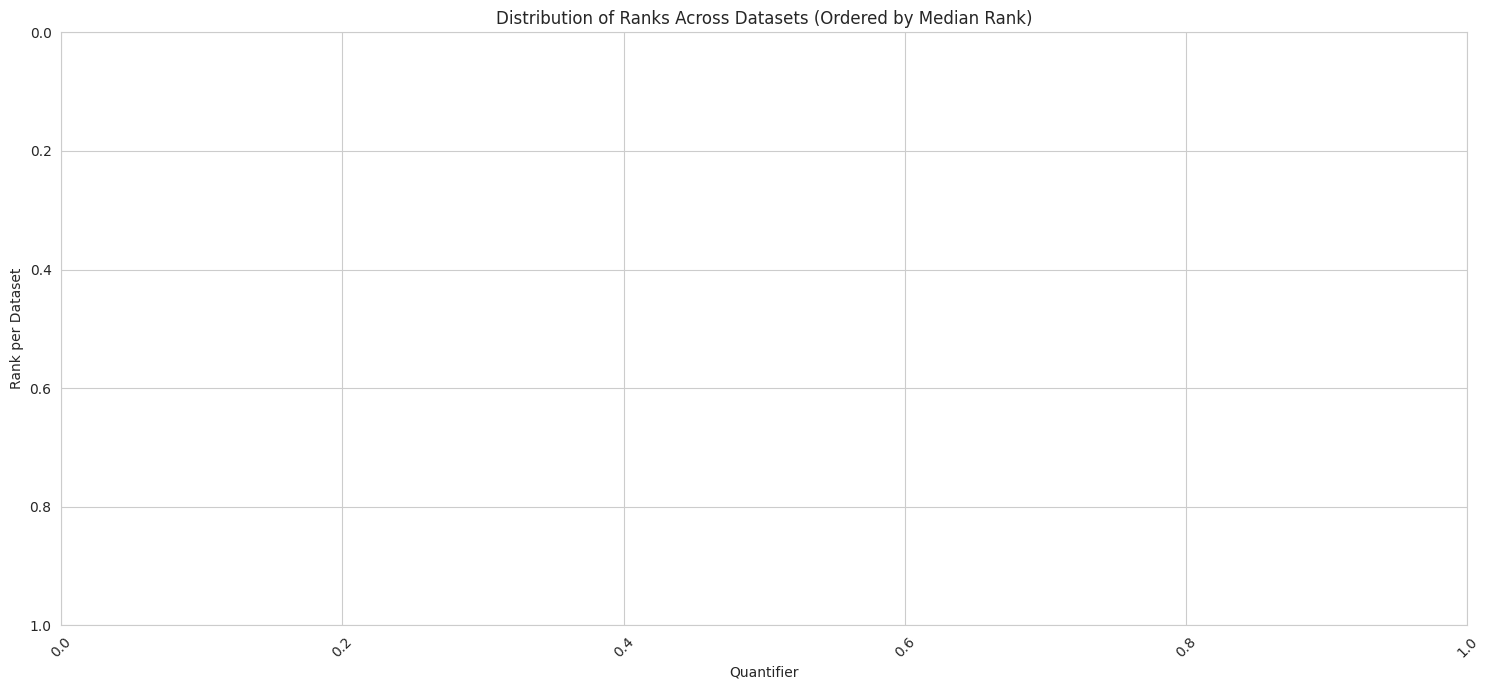

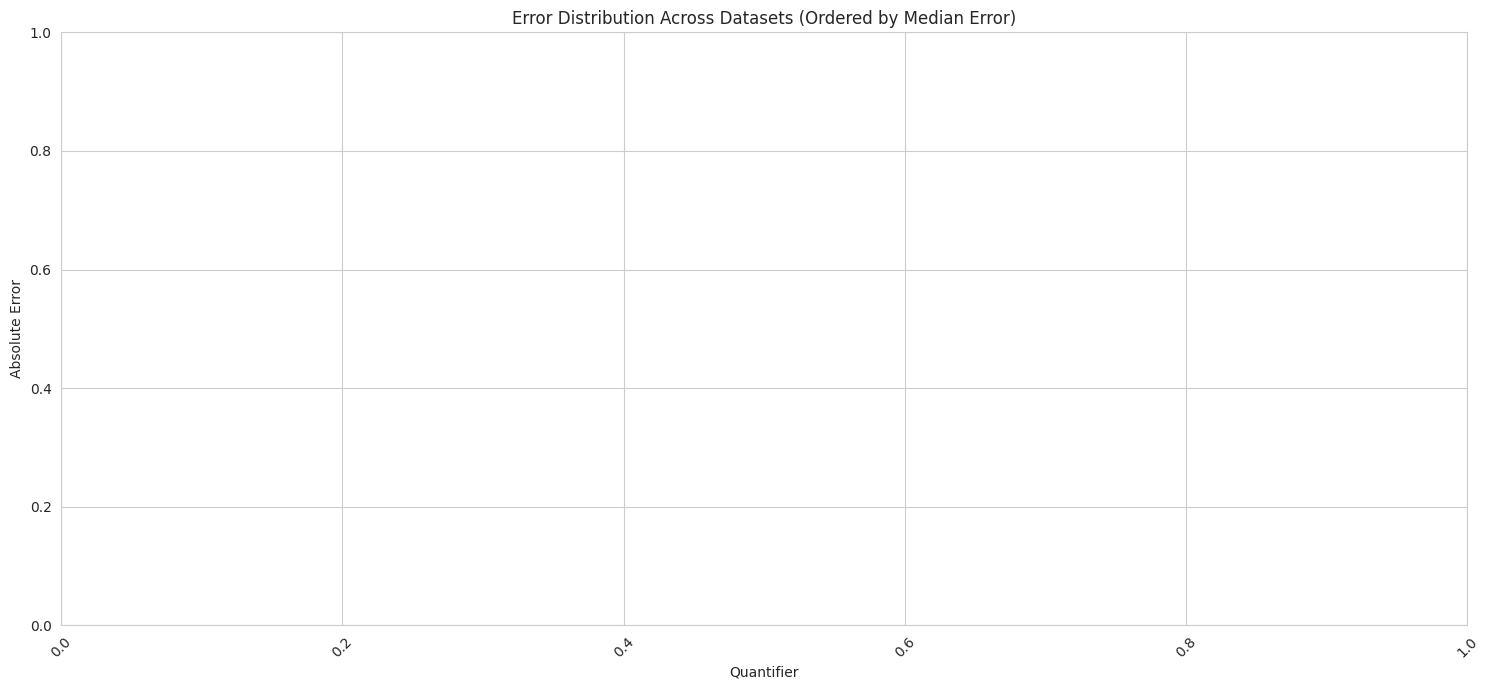


===== GLOBAL MEAN ERROR =====
Empty DataFrame
Columns: [modelo, mean_error]
Index: []

===== GLOBAL MEDIAN ERROR - Código A =====
Empty DataFrame
Columns: [modelo, median_error]
Index: []

===== RESULTS TABLE =====
Empty DataFrame
Columns: []
Index: []

===== RANK TABLE =====
Empty DataFrame
Columns: []
Index: []

✅ ANALYSIS FINISHED

Arquivos gerados:
 - average_rank_filtered.csv
 - global_mean_error_filtered.csv
 - global_median_error_filtered.csv
 - results_by_dataset_and_classes.csv
 - rank_table_per_dataset.csv
 - rank_boxplot_filtered.png
 - error_boxplot_filtered.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "exp_results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# DATASETS ORIGINAIS
# ============================================================

all_datasets = sorted(df["dataset"].unique())

print(f"\nTotal original datasets: {len(all_datasets)}")

# ============================================================
# REMOVER MODELOS
# ============================================================

modelos_remover = [
    #"KDEyHD",
    #"KDEyCS",
    #"EMQ_BCTS",
    "ClusterQuant"
]

df_filtered = df[
    ~df["modelo"].isin(modelos_remover)
].copy()

# ============================================================
# MODELOS RESTANTES
# ============================================================

remaining_models = sorted(
    df_filtered["modelo"].unique()
)

print("\n===== MODELOS RESTANTES =====")
print(remaining_models)

print(f"\nTotal remaining models: {len(remaining_models)}")

# ============================================================
# GARANTIR DATASETS COMPLETOS
# ============================================================
# Mantém apenas datasets que possuem TODOS os
# modelos restantes
# ============================================================

dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index

df = df_filtered[
    df_filtered["dataset"].isin(valid_datasets)
].copy()

print(f"\nDatasets completos restantes: {len(valid_datasets)}")

missing_datasets = set(all_datasets) - set(valid_datasets)

if len(missing_datasets) > 0:
    print("\n⚠️ DATASETS REMOVIDOS (incompletos):")
    for d in sorted(missing_datasets):
        print(d)

# ============================================================
# CHECAGEM FINAL
# ============================================================

final_check = (
    df.groupby("dataset")["modelo"]
    .nunique()
)

assert (final_check == len(remaining_models)).all()

print("\n✅ Todos os datasets possuem todos os modelos restantes.")

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

#avg_rank.to_csv(
#    "average_rank_filtered.csv",
#    index=False
#)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR - Código A =====")
print(global_median_error)

# ============================================================
# TABELA FINAL COM NÚMERO DE CLASSES
# ============================================================
# ESTE BLOCO ASSUME QUE EXISTE UMA COLUNA:
#   - "n_classes"
# OU:
#   - "classes"
#
# Se o nome for diferente, apenas troque abaixo.
# ============================================================

N_CLASSES_COLUMN = "n_classes_original"

# média por dataset/modelo
dataset_table = (
    df.groupby(
        ["dataset", N_CLASSES_COLUMN, "modelo"]
    )["erro"]
    .mean()
    .reset_index()
)

# pivot table
results_table = dataset_table.pivot_table(
    index=["dataset", N_CLASSES_COLUMN],
    columns="modelo",
    values="erro"
)

# ordenar datasets pelo número de classes
results_table = results_table.sort_index(level=1)

# arredondar
results_table = results_table.round(6)

print("\n===== RESULTS TABLE =====")
print(results_table)

# salvar csv
results_table.to_csv(
    "results_by_dataset_and_classes.csv"
)

# ============================================================
# TABELA COM RANKS POR DATASET
# ============================================================

rank_table = (
    dataset_mean.pivot_table(
        index="dataset",
        columns="modelo",
        values="rank_dataset"
    )
    .round(3)
)

print("\n===== RANK TABLE =====")
print(rank_table)

#rank_table.to_csv(
#    "rank_table_per_dataset.csv"
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - results_by_dataset_and_classes.csv")
print(" - rank_table_per_dataset.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")

In [4]:
import pandas as pd

# =====================================================
# LOAD
# =====================================================

df = pd.read_csv("exp_results.csv")

# =====================================================
# AGRUPAR QMOSS
# =====================================================

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# =====================================================
# MÉDIA POR DATASET/MODELO
# =====================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# =====================================================
# RANK DENTRO DE CADA DATASET
# =====================================================

dataset_mean["rank"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average", ascending=True)
)

# =====================================================
# TABELA DATASET x RANK
# =====================================================

rank_table = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="rank"
)

# =====================================================
# ORDENAR COLUNAS PELO RANK MÉDIO
# =====================================================

avg_rank = rank_table.mean(axis=0)

rank_table = rank_table[
    avg_rank.sort_values().index
]

# =====================================================
# SALVAR
# =====================================================

rank_table.to_csv(
    "rank_por_dataset.csv"
)

print(rank_table.round(2))

modelo            KDEyML  KDEyHD  KDEyCS  EMQ_MLQ   PAC  EMQ_QUAPY    AC  \
dataset                                                                    
abalone             13.0    10.0     8.0      5.0  15.0        6.0  14.0   
academic-success     3.0     2.0     1.0      8.0   4.0        7.0   5.0   
chess                1.0     7.0     4.0      3.0   5.0        2.0   8.0   
cmc                  2.0     1.0     7.0      3.0   5.0        4.0   8.0   
connect-4            4.0     1.0     2.0      6.0   3.0        5.0   8.0   
digits               1.0     7.0     8.0      9.0   6.0       10.0   3.0   
dry-bean             1.0     6.0     8.0      2.0   5.0        3.0   7.0   
hand_digits          1.0    10.0     9.0      7.0   6.0        8.0   2.0   
hcv                 16.0     8.0     9.0     10.0  13.0       12.0  11.0   
image_seg            2.0    10.0     3.0      5.0   1.0        6.0   9.0   
isolet               1.0     7.0     5.0      9.0   6.0       10.0   3.0   
letter      

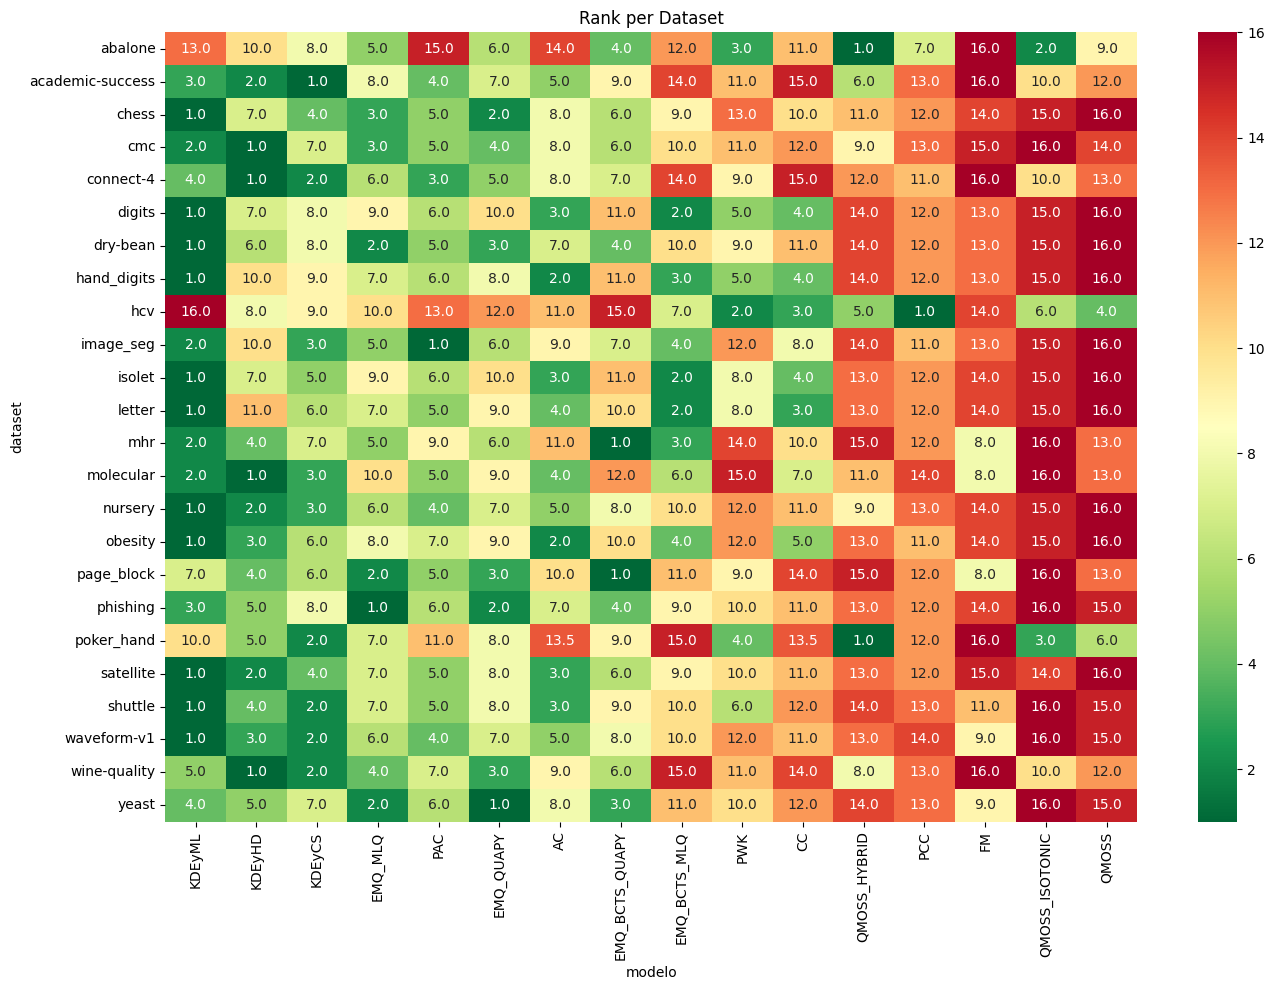

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("exp_results.csv")

# -----------------------------------
# Agrupar QMOSS
# -----------------------------------

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# -----------------------------------
# Média por dataset/modelo
# -----------------------------------

dataset_mean = (
    df.groupby(["dataset","modelo"])["erro"]
      .mean()
      .reset_index()
)

# -----------------------------------
# Rank dentro de cada dataset
# -----------------------------------

dataset_mean["rank"] = (
    dataset_mean
    .groupby("dataset")["erro"]
    .rank(method="average")
)

# -----------------------------------
# Pivot
# -----------------------------------

heat = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="rank"
)

# ordenar colunas pelo rank médio

ordem = (
    dataset_mean.groupby("modelo")["rank"]
    .mean()
    .sort_values()
    .index
)

heat = heat[ordem]

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    heat,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r"
)

plt.title("Rank per Dataset")
plt.tight_layout()
plt.show()

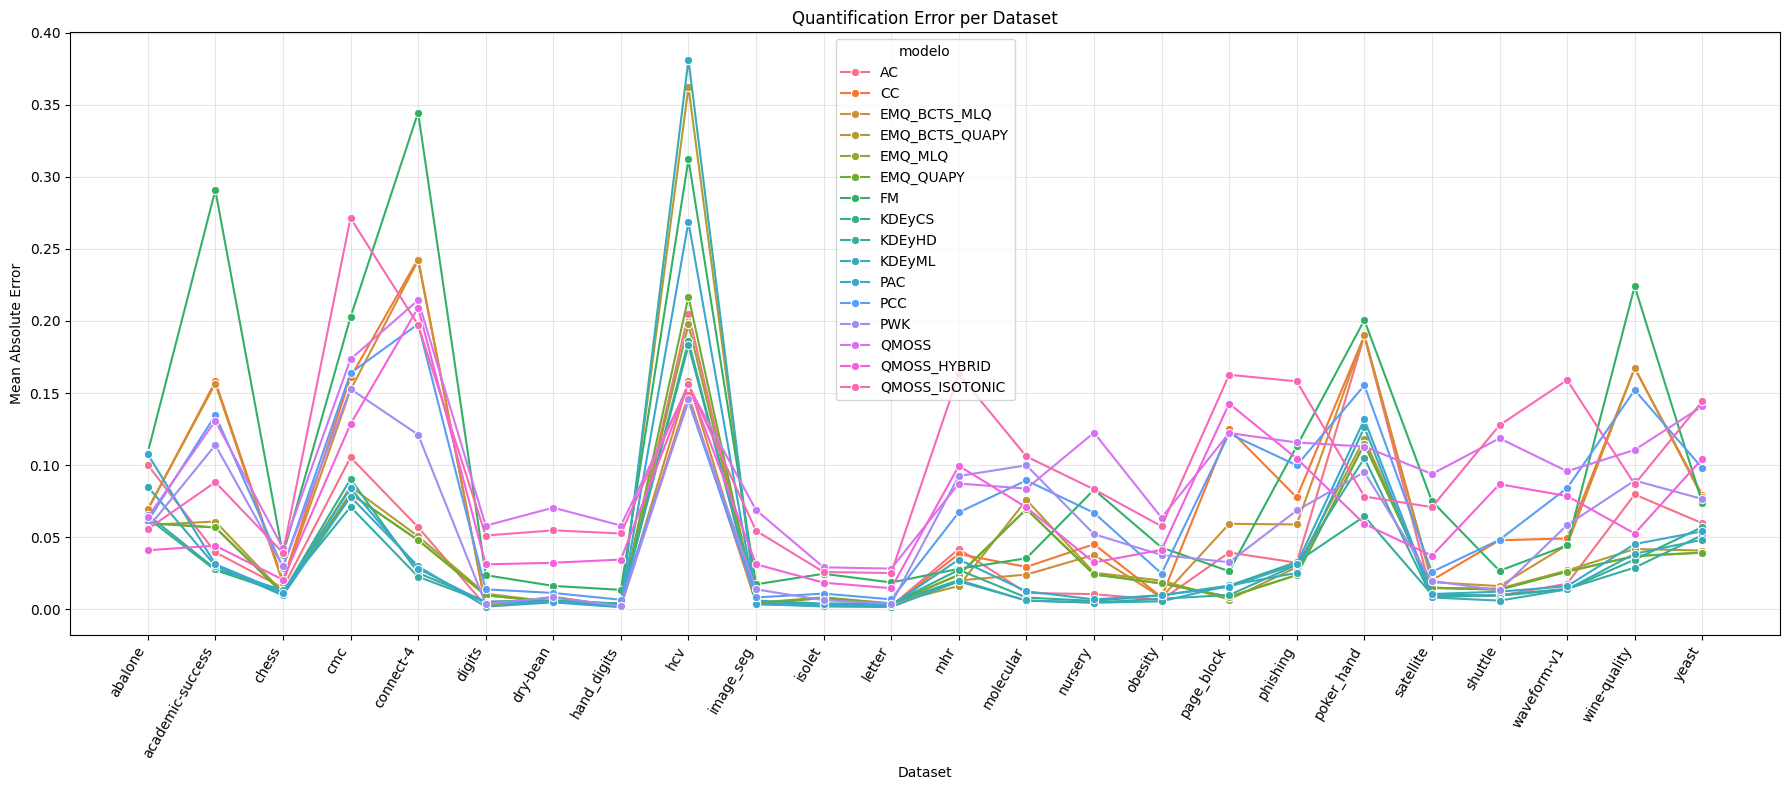

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("exp_results.csv")

# ----------------------------------
# Agrupar QMOSS
# ----------------------------------

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# ----------------------------------
# Média por dataset/modelo
# ----------------------------------

dataset_mean = (
    df.groupby(["dataset","modelo"])["erro"]
      .mean()
      .reset_index()
)

# ----------------------------------
# Ordem dos datasets
# ----------------------------------

dataset_order = (
    dataset_mean.groupby("dataset")["erro"]
    .mean()
    .sort_values()
    .index
)

# ----------------------------------
# Plot
# ----------------------------------

plt.figure(figsize=(18,8))

sns.lineplot(
    data=dataset_mean,
    x="dataset",
    y="erro",
    hue="modelo",
    marker="o"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel("Mean Absolute Error")
plt.xlabel("Dataset")

plt.title(
    "Quantification Error per Dataset"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [11]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("exp_results.csv")

# ----------------------------------
# Agrupar QMOSS
# ----------------------------------

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# ----------------------------------
# Média por dataset/modelo
# ----------------------------------

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
      .mean()
      .reset_index()
)

# ----------------------------------
# Ordenar datasets por dificuldade
# ----------------------------------

dataset_order = (
    dataset_mean.groupby("dataset")["erro"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

dataset_mean["dataset"] = pd.Categorical(
    dataset_mean["dataset"],
    categories=dataset_order,
    ordered=True
)

dataset_mean = dataset_mean.sort_values("dataset")

# ----------------------------------
# Plot
# ----------------------------------

fig = px.line(
    dataset_mean,
    x="dataset",
    y="erro",
    color="modelo",
    markers=True,
    title="Quantification Error per Dataset",
    labels={
        "erro": "Mean Absolute Error",
        "dataset": "Dataset",
        "modelo": "Quantifier"
    }
)

fig.update_layout(
    width=1400,
    height=700,
    xaxis_tickangle=-60,
    legend_title="Model",
    hovermode="x unified"
)

fig.update_traces(
    line=dict(width=2),
    marker=dict(size=6)
)

fig.show()